In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar dados limpos

import pandas as pd

# url = 'https://raw.githubusercontent.com/Pf_pipeline_dados/main/Projeto_final_analise_credito/dados_credito.xlsx'
# df = pd.read_excel(url, engine='openpyxl')
# df.to_csv('dados_credito.csv', index=False)

df = pd.read_csv("dados_tratados (1).csv")

print("="*50)
print("RELATÓRIO DE QUALIDADE DE DADOS")
print("="*50)

RELATÓRIO DE QUALIDADE DE DADOS


In [20]:
# 1. COMPLETUDE

print("\n1. COMPLETUDE DOS DADOS")
print("-" * 50)

total_celulas = df.shape[0] * df.shape[1]
celulas_preenchidas = df.count().sum()
completude_geral = (celulas_preenchidas / total_celulas) * 100
print(f"\nCompletude Geral: {completude_geral:.2f}%")

print("\nCompletude por coluna:")
for coluna in df.columns:
    valores_preenchidos = df[coluna].count()
    total = len(df)
    percentual = (valores_preenchidos / total) * 100
    print(f" {coluna}: {percentual:.2f}%")



1. COMPLETUDE DOS DADOS
--------------------------------------------------

Completude Geral: 100.00%

Completude por coluna:
 CODIGO_CLIENTE: 100.00%
 UF: 100.00%
 IDADE: 100.00%
 ESCOLARIDADE: 100.00%
 ESTADO_CIVIL: 100.00%
 QT_FILHOS: 100.00%
 CASA_PROPRIA: 100.00%
 QT_IMOVEIS: 100.00%
 VL_IMOVEIS: 100.00%
 OUTRA_RENDA: 100.00%
 OUTRA_RENDA_VALOR: 100.00%
 TEMPO_ULTIMO_EMPREGO_MESES: 100.00%
 TRABALHANDO_ATUALMENTE: 100.00%
 ULTIMO_SALARIO: 100.00%
 QT_CARROS: 100.00%
 VALOR_TABELA_CARROS: 100.00%
 SCORE: 100.00%
 FAIXA_ETARIA: 100.00%
 TEM_FILHOS: 100.00%
 RENDA_TOTAL: 100.00%
 CATEGORIA_RENDA: 100.00%


In [11]:
# 2. UNICIDADE

print("\n2. UNICIDADE DOS DADOS")
print("-" * 50)

duplicatas = df.duplicated().sum()
unicidade = ((len(df) - duplicatas) / len(df)) * 100
print(f"Linhas únicas: {unicidade:.2f}%")
print(f"Duplicatas encontradas: {duplicatas}")


2. UNICIDADE DOS DADOS
--------------------------------------------------
Linhas únicas: 100.00%
Duplicatas encontradas: 0


In [29]:
# 3. CONSISTÊNCIA

print("\n3. CONSISTÊNCIA DOS DADOS")
print("-" * 50)

# Exemplo: verificar se valores numéricos são positivos
for coluna in ['CODIGO_CLIENTE', 'IDADE', 'QT_FILHOS', 'QT_IMOVEIS', 'VL_IMOVEIS', 'TEMPO_ULTIMO_EMPREGO_MESES', 'ULTIMO_SALARIO', 'QT_CARROS', 'RENDA_TOTAL', 'VALOR_TABELA_CARROS', 'SCORE', 'VALOR_TABELA_CARROS' ]:
  if coluna in df.columns:
    negativos = (df[coluna] < 0).sum()
    print(f"{coluna}: {negativos} valores negativos encontrados")

# Exemplo: verificar se datas estão no passado
# if 'data_compra' in df.columns:
#     df['data_compra'] = pd.to_datetime(df['data_compra'])
#     futuras = (df['data_compra'] > pd.Timestamp.now()).sum()
#     print(f"Datas no futuro: {futuras}")


3. CONSISTÊNCIA DOS DADOS
--------------------------------------------------
CODIGO_CLIENTE: 0 valores negativos encontrados
IDADE: 0 valores negativos encontrados
QT_FILHOS: 0 valores negativos encontrados
QT_IMOVEIS: 0 valores negativos encontrados
VL_IMOVEIS: 0 valores negativos encontrados
TEMPO_ULTIMO_EMPREGO_MESES: 0 valores negativos encontrados
ULTIMO_SALARIO: 0 valores negativos encontrados
QT_CARROS: 0 valores negativos encontrados
RENDA_TOTAL: 0 valores negativos encontrados
VALOR_TABELA_CARROS: 0 valores negativos encontrados
SCORE: 0 valores negativos encontrados
VALOR_TABELA_CARROS: 0 valores negativos encontrados


In [35]:
# 4. VALIDADE

print("\n4. VALIDADE DOS DADOS")
print("-" * 50)

# verificar ranges válidos
validacoes = {
    'CODIGO_CLIENTE': (1, 999999999),
    'IDADE': (0, 120),
    'QT_FILHOS': (0, 20),
    'QT_IMOVEIS': (0, 50),
    'VL_IMOVEIS': (0, 1_000_000_000),
    'TEMPO_ULTIMO_EMPREGO_MESES': (0, 600),
    'ULTIMO_SALARIO': (0, 1_000_000),
    'QT_CARROS': (0, 20),
    'RENDA_TOTAL': (0, 2_000_000),
    'VALOR_TABELA_CARROS': (0, 2_000_000),
    'SCORE': (0, 1000)
}

for coluna, (min_val, max_val) in validacoes.items():
    if coluna in df.columns:
        fora_range = ((df[coluna] < min_val) | (df[coluna] > max_val)).sum()
        print(f"{coluna}: {fora_range} valores fora do intervalo válido ({min_val} – {max_val})")
    else:
        print(f"{coluna}: coluna não encontrada no DataFrame.")


# Exemplo: verificar ranges válidos
# if 'IDADE' in df.columns:
#   fora_range = ((df['IDADE'] < 0) | (df['IDADE'] > 120)).sum()
#   print(f"Idades inválidas: {fora_range}")


4. VALIDADE DOS DADOS
--------------------------------------------------
CODIGO_CLIENTE: 0 valores fora do intervalo válido (1 – 999999999)
IDADE: 0 valores fora do intervalo válido (0 – 120)
QT_FILHOS: 2 valores fora do intervalo válido (0 – 20)
QT_IMOVEIS: 0 valores fora do intervalo válido (0 – 50)
VL_IMOVEIS: 0 valores fora do intervalo válido (0 – 1000000000)
TEMPO_ULTIMO_EMPREGO_MESES: 0 valores fora do intervalo válido (0 – 600)
ULTIMO_SALARIO: 0 valores fora do intervalo válido (0 – 1000000)
QT_CARROS: 0 valores fora do intervalo válido (0 – 20)
RENDA_TOTAL: 0 valores fora do intervalo válido (0 – 2000000)
VALOR_TABELA_CARROS: 0 valores fora do intervalo válido (0 – 2000000)
SCORE: 0 valores fora do intervalo válido (0 – 1000)



Gráfico de qualidade salvo em: data/quality_report.png


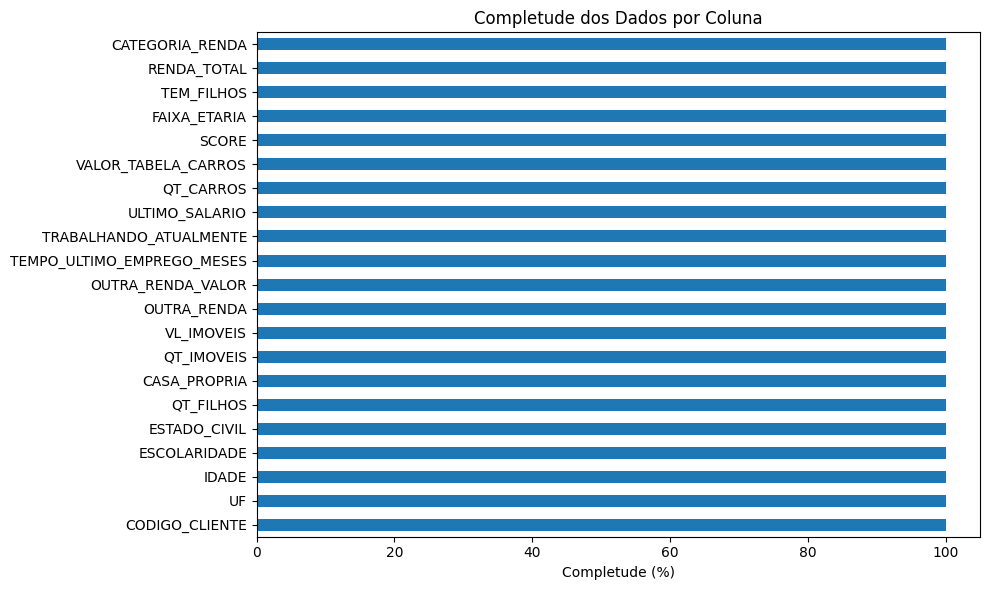

In [26]:
# 5. VISUALIZAÇÃO
# Gráfico de completude
plt.figure(figsize=(10, 6))
completude_por_coluna = (df.count() / len(df) * 100).sort_values()
completude_por_coluna.plot(kind='barh')
plt.xlabel('Completude (%)')
plt.title('Completude dos Dados por Coluna')
plt.tight_layout()
plt.savefig('quality_report.png')
print("\nGráfico de qualidade salvo em: data/quality_report.png")

In [27]:
# SCORE FINAL
print("\n" + "="*50)
print("SCORE GERAL DE QUALIDADE")
print("="*50)
# Score simples: média de completude e unicidade
score_final = (completude_geral + unicidade) / 2
print(f"Score Final: {score_final:.2f}%")
if score_final >= 90:
  print("Classificação: EXCELENTE")
elif score_final >= 80:
  print("Classificação: BOM")
elif score_final >= 70:
  print("Classificação: REGULAR")
else:
  print("Classificação: NECESSITA MELHORIAS")


SCORE GERAL DE QUALIDADE
Score Final: 100.00%
Classificação: EXCELENTE
